In [1]:
import math
from utility import fit
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import torch
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from datetime import datetime
from tqdm import tqdm
from torch.optim import LBFGS
import torch.nn as nn

################################
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

/home/defuser/miniconda3/envs/KAN/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuda


In [2]:
class NaiveFourierKANLayer(nn.Module):
    def __init__(self, inputdim, outdim, gridsize, addbias=True, smooth_initialization=False):
        super(NaiveFourierKANLayer, self).__init__()
        self.gridsize = gridsize
        self.addbias = addbias
        self.inputdim = inputdim
        self.outdim = outdim

        grid_norm_factor = (torch.arange(gridsize) + 1) ** 2 if smooth_initialization else np.sqrt(gridsize)

        self.fouriercoeffs = nn.Parameter(torch.randn(2, outdim, inputdim, gridsize) /
                                          (np.sqrt(inputdim) * grid_norm_factor))
        if self.addbias:
            self.bias = nn.Parameter(torch.zeros(1, outdim))

    def forward(self, x):
        xshp = x.shape
        outshape = xshp[0:-1] + (self.outdim,)
        x = torch.reshape(x, (-1, self.inputdim))
        k = torch.reshape(torch.arange(1, self.gridsize + 1, device=x.device), (1, 1, 1, self.gridsize))
        xrshp = torch.reshape(x, (x.shape[0], 1, x.shape[1], 1))
        c = torch.cos(k * xrshp)
        s = torch.sin(k * xrshp)
        y = torch.sum(c * self.fouriercoeffs[0:1], (-2, -1))
        y += torch.sum(s * self.fouriercoeffs[1:2], (-2, -1))
        if self.addbias:
            y += self.bias
        y = torch.reshape(y, outshape)
        return y


In [3]:
class fKAN(nn.Module):
    def __init__(self, layers, gridsizes):
        super(fKAN, self).__init__()
        self.layers = nn.ModuleList()
        for i in range(len(layers) - 2):
            self.layers.append(NaiveFourierKANLayer(layers[i], layers[i + 1], gridsize=gridsizes[i]))
        self.layers.append(nn.Linear(layers[len(layers) - 2], layers[len(layers) - 1]))

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

def objective(trial):
    depth = trial.suggest_int("depth", 1, MAX_DEPTH)
    width = [trial.suggest_int(f"neurons_layer_{i}", 5, MAX_NEURONS, step=5) for i in range(depth)]
    grids = [trial.suggest_int(f"grids_{i}", 1, MAX_GRID) for i in range(depth)]
    width = [input_shape] + width + [output_shape]
    model = fKAN(width, grids).to(device)

    history = fit(model, dataset, steps=EPOCHS, loss_fn=torch.nn.CrossEntropyLoss())

    y_score = model(X_valid).cpu()
    y_pred = (y_score > 0.5).int()

    return f1_score(y_valid.cpu(), y_pred, average="macro")

In [4]:
best_params_CA = {
    "depth": 2,
    "grids_0": 8,
    "grids_1": 3,
    "neurons_layer_0": 30,
    "neurons_layer_1": 35
}

In [5]:
EPOCHS = 100

DATA = 'CA'

data = pd.read_csv("/home/data3/Ali/Code/KAN/Afzal/DATA/%s.csv" % DATA)

data.fillna(0, inplace=True)
y = data["target_label"].values
data.drop("target_label", axis=1, inplace=True)
X = data.values.astype(np.float32)

if y.dtype == "object":
    label_encoder = LabelEncoder()
    y = torch.tensor(label_encoder.fit_transform(y))
else:
    y = torch.tensor(y)


X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, stratify=y_train, test_size=0.1, random_state=42)

scaler = StandardScaler()
X_train = torch.tensor(scaler.fit_transform(X_train)).to(device)
X_valid = torch.tensor(scaler.transform(X_valid)).to(device)
X_test = torch.tensor(scaler.transform(X_test)).to(device)

y_train = torch.nn.functional.one_hot(y_train.long(), num_classes=2).to(device).float()
y_valid = torch.nn.functional.one_hot(y_valid.long(), num_classes=2).to(device).float()
y_test = torch.nn.functional.one_hot(y_test.long(), num_classes=2).to(device).float()

input_shape = X_train.shape[1]
output_shape = y_train.shape[1]

dataset = {
"train_input": X_train,
"train_label": y_train,
"test_input": X_valid,
"test_label": y_valid,
}

best_params = best_params_CA
print('best_params:', best_params)

depth = best_params["depth"]
width = [best_params[f"neurons_layer_{i}"] for i in range(depth)]
width = [input_shape] + width + [output_shape]
grids = [best_params[f"grids_{i}"] for i in range(depth)]

model = fKAN(width, grids).to(device)
history = fit(model, dataset, steps=EPOCHS, loss_fn=torch.nn.CrossEntropyLoss())

y_score = model(X_test).cpu()
y_pred = (y_score > 0.5).int()

print(classification_report(y_test.cpu(), y_pred, target_names=label_encoder.classes_))
print("ROC-AUC: %.4f" % roc_auc_score(y_test.cpu(), y_pred))

best_params: {'depth': 2, 'grids_0': 8, 'grids_1': 3, 'neurons_layer_0': 30, 'neurons_layer_1': 35}


| train_loss: -0.00e+00 | test_loss: 1.67e+00 : 100%|█████████████| 100/100 [00:03<00:00, 31.71it/s]


              precision    recall  f1-score   support

           +       0.88      0.79      0.84        77
           -       0.82      0.91      0.86        77

   micro avg       0.85      0.85      0.85       154
   macro avg       0.85      0.85      0.85       154
weighted avg       0.85      0.85      0.85       154
 samples avg       0.85      0.85      0.85       154

ROC-AUC: 0.8506


/home/defuser/miniconda3/envs/KAN/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Interpretebility

In [6]:
model

fKAN(
  (layers): ModuleList(
    (0-1): 2 x NaiveFourierKANLayer()
    (2): Linear(in_features=35, out_features=2, bias=True)
  )
)

In [17]:
# Get the first NaiveFourierKANLayer
fourier_layer = model.layers[0]

# Extract coefficients (shape: [2, outdim, inputdim, gridsize])
cos_coeffs = fourier_layer.fouriercoeffs[0].detach().cpu().numpy()  # Cosine coefficients
sin_coeffs = fourier_layer.fouriercoeffs[1].detach().cpu().numpy()  # Sine coefficients

# Parameters from best_params
inputdim = fourier_layer.inputdim  # Number of input features
outdim = best_params["neurons_layer_0"]  # 30 (from best_params["neurons_layer_0"])
gridsize = best_params["grids_0"]  # 8 (from best_params["grids_0"])

In [18]:
import numpy as np

def fourier_series(x, cos_coeffs, sin_coeffs, gridsize, feature_idx):
    """
    Compute the aggregated Fourier series for feature `i` across all outputs.
    """
    y = np.zeros_like(x)
    for output_idx in range(outdim):
        for k in range(1, gridsize + 1):
            # Get coefficients for feature i, output j, grid point k-1
            c_cos = cos_coeffs[output_idx, feature_idx, k-1]
            c_sin = sin_coeffs[output_idx, feature_idx, k-1]
            y += c_cos * np.cos(k * x) + c_sin * np.sin(k * x)
    return y / outdim  # Average over all outputs

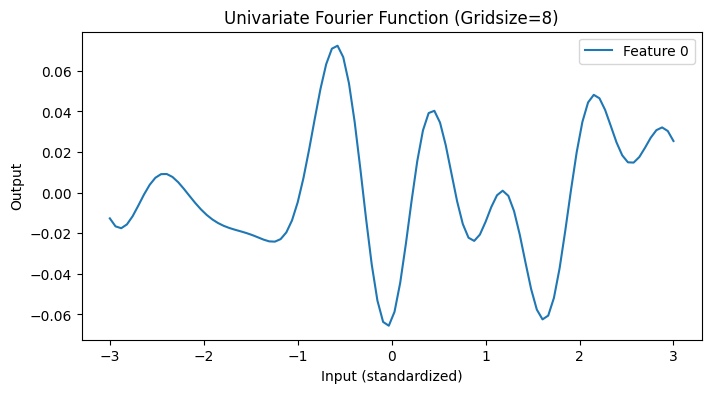

In [19]:
import matplotlib.pyplot as plt

# Generate input values (standardized)
x = np.linspace(-3, 3, 100)

# Choose a feature to visualize (e.g., feature 0)
feature_idx = 0
y = fourier_series(x, cos_coeffs, sin_coeffs, gridsize, feature_idx)

# Plot
plt.figure(figsize=(8, 4))
plt.plot(x, y, label=f'Feature {feature_idx}')
plt.xlabel('Input (standardized)')
plt.ylabel('Output')
plt.title(f'Univariate Fourier Function (Gridsize={gridsize})')
plt.legend()
plt.show()

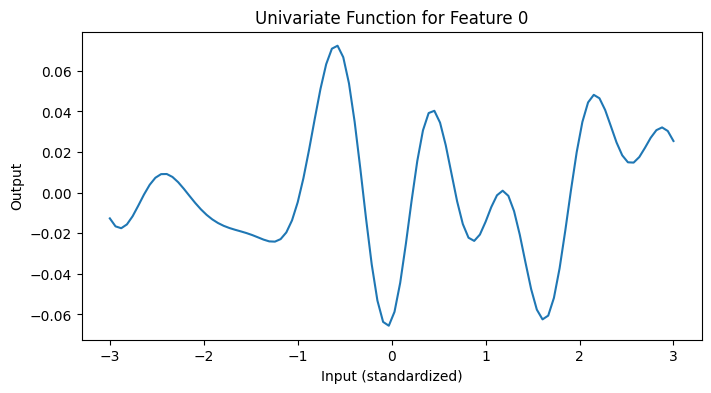

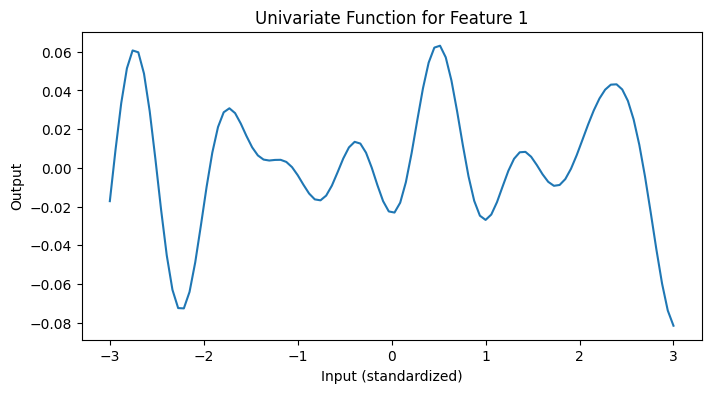

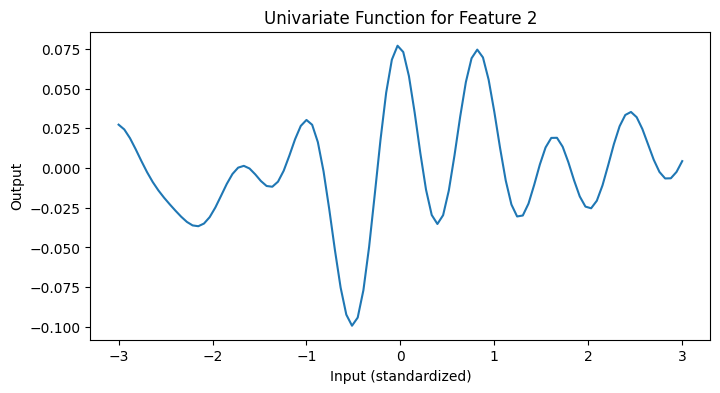

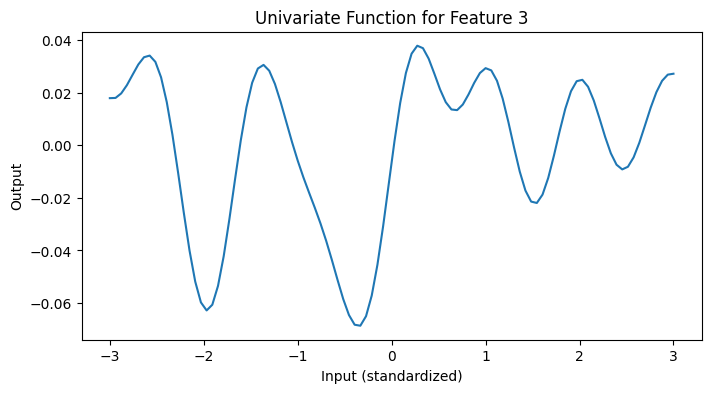

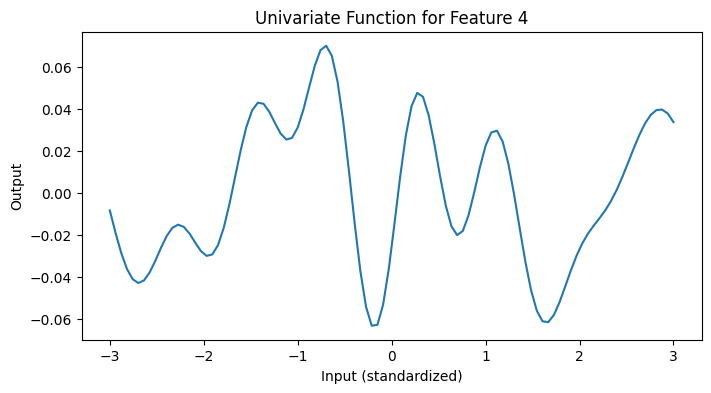

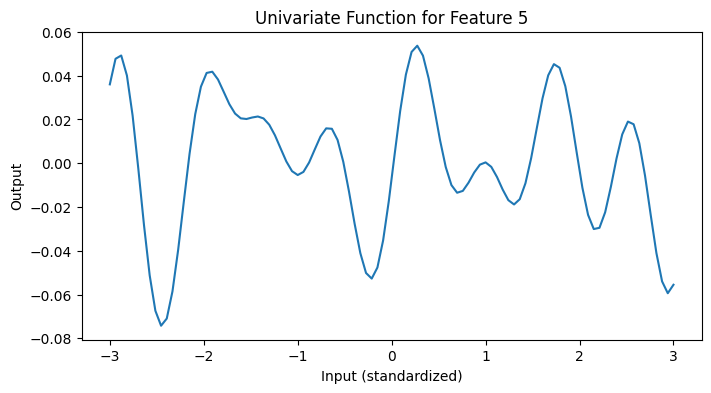

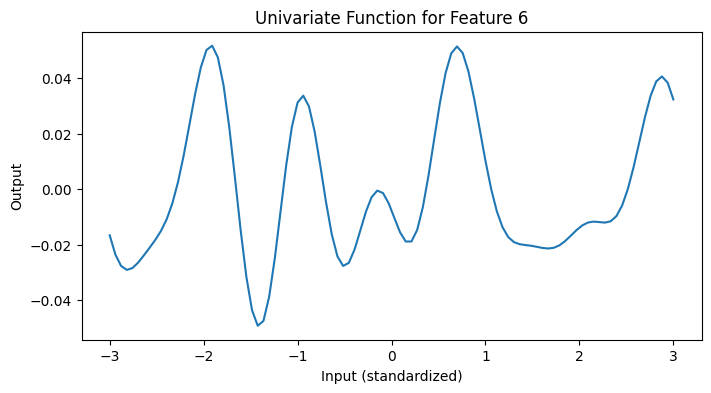

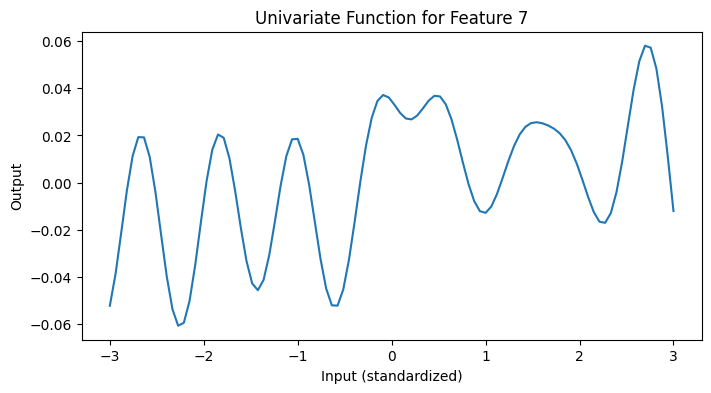

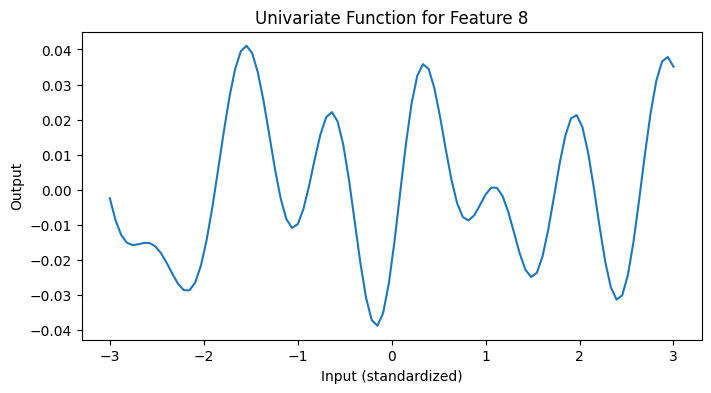

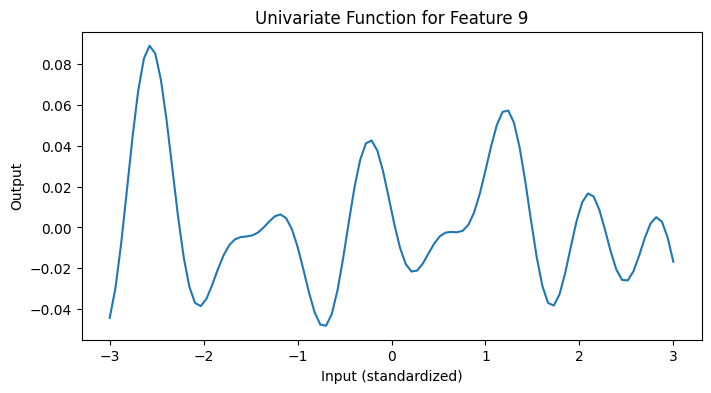

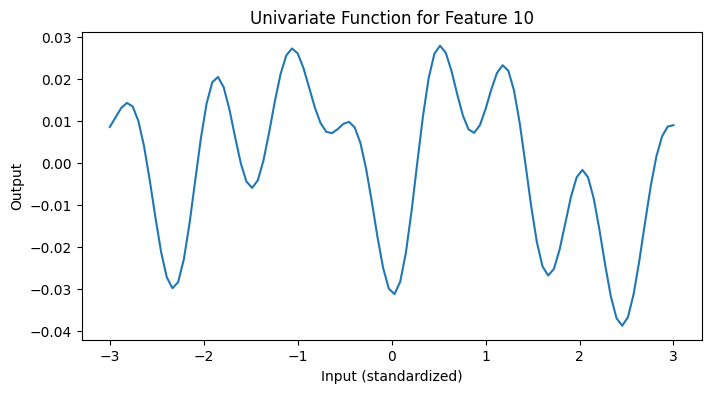

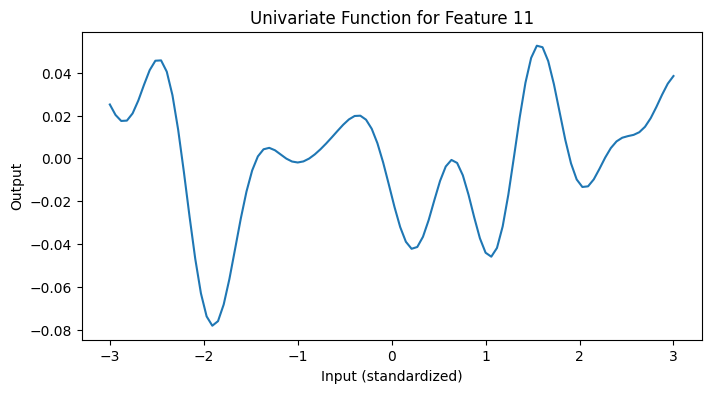

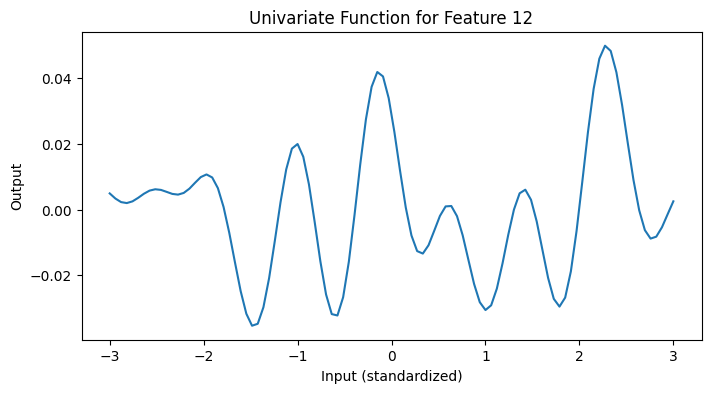

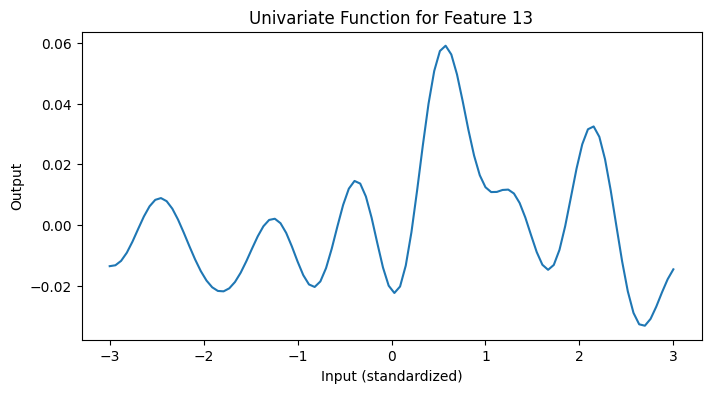

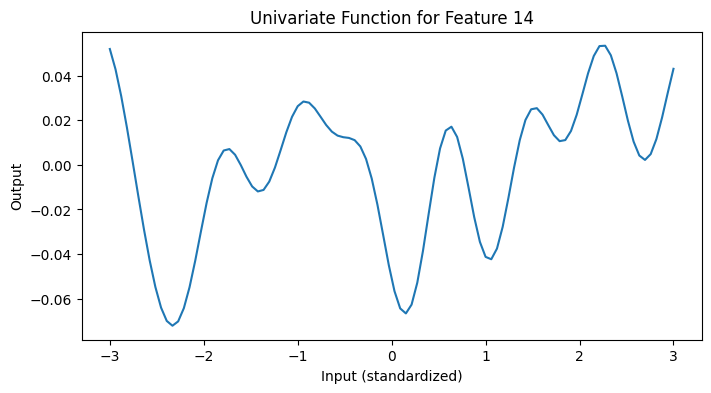

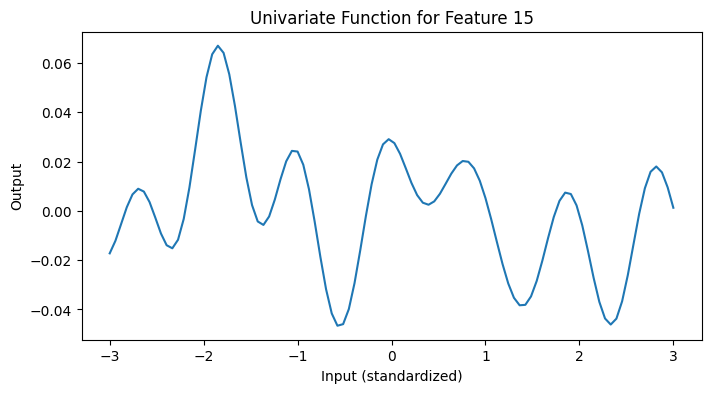

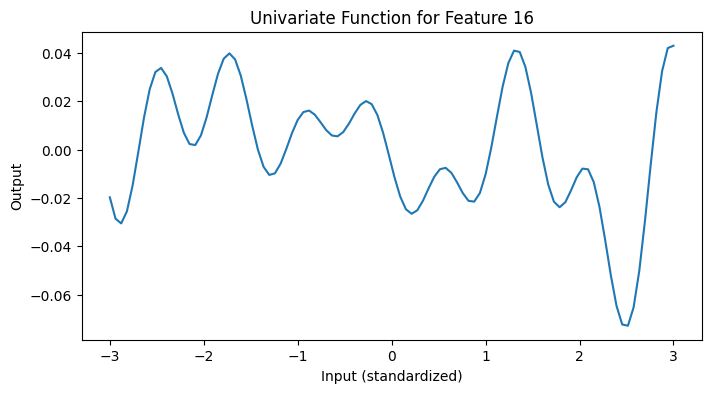

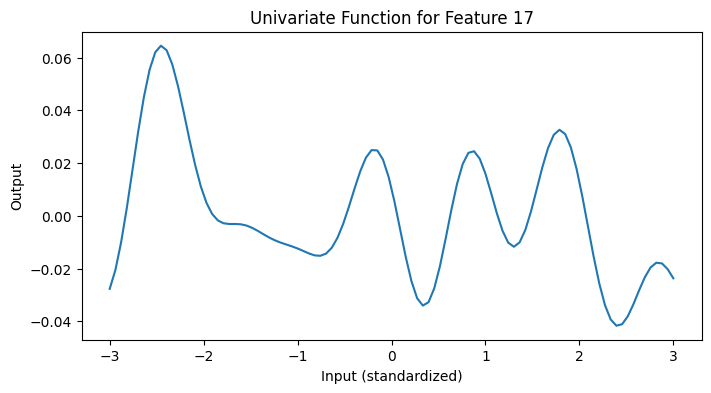

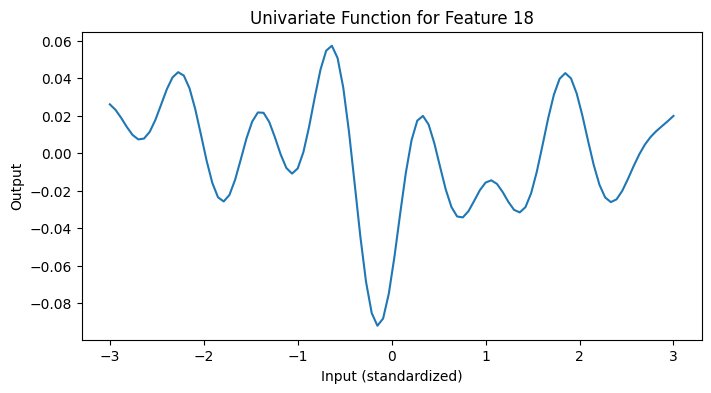

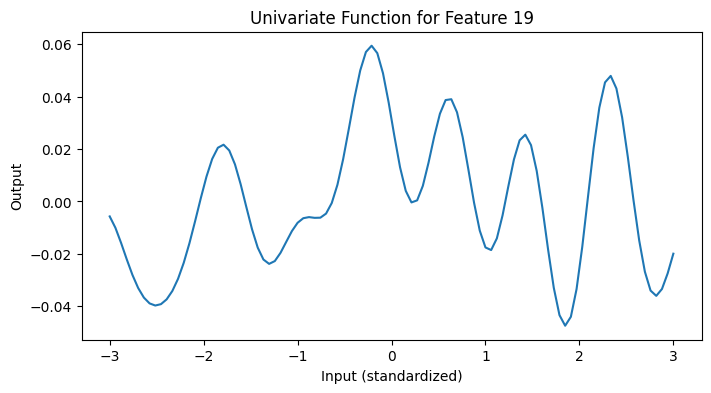

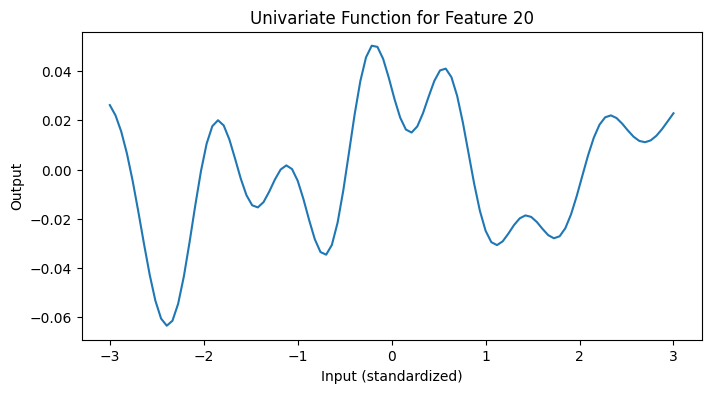

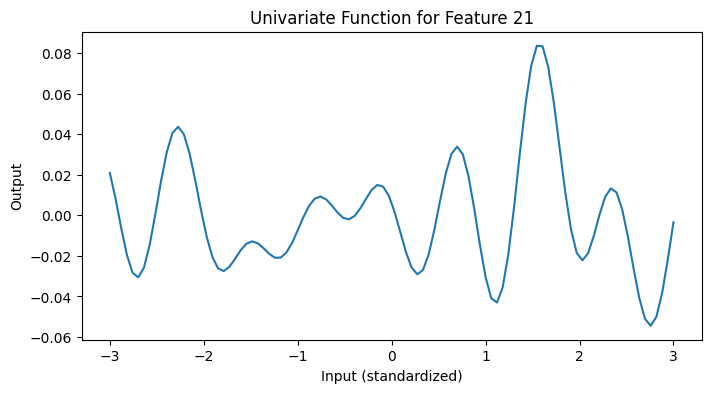

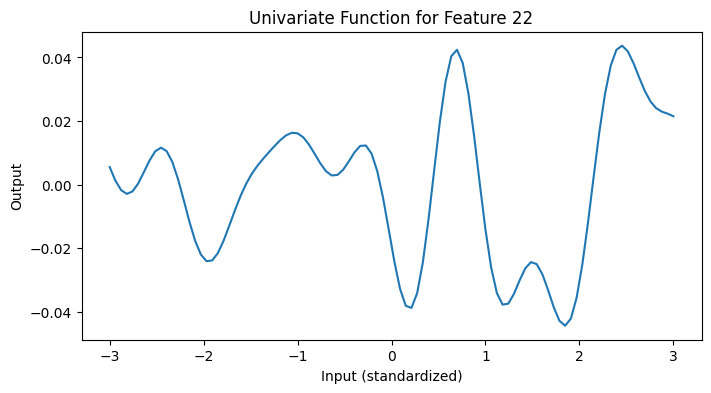

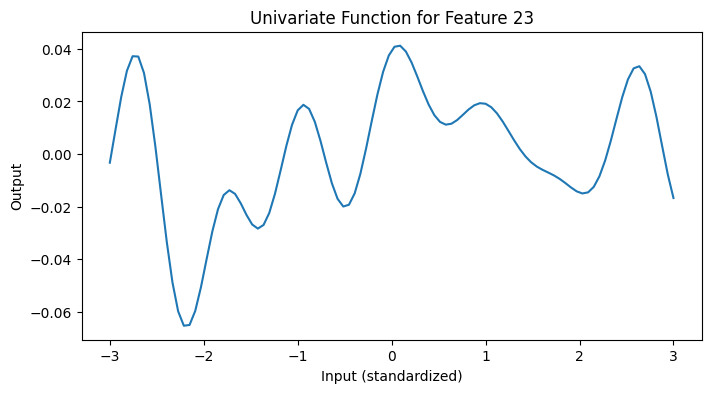

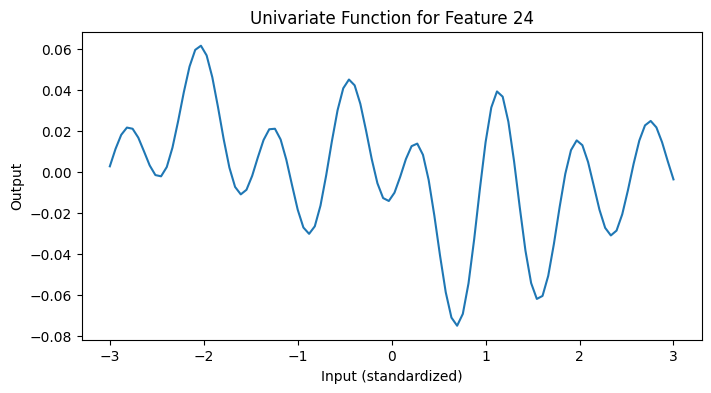

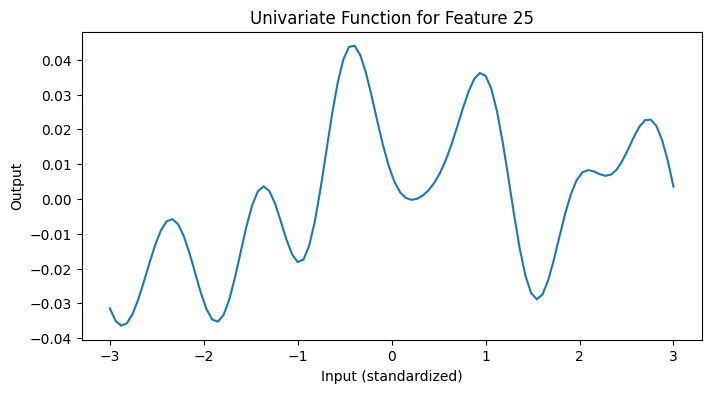

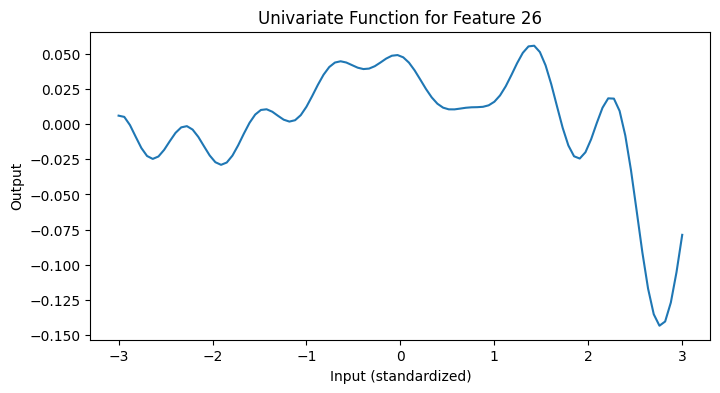

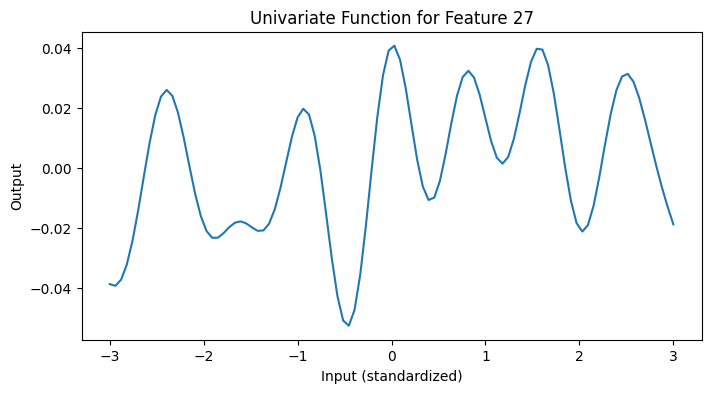

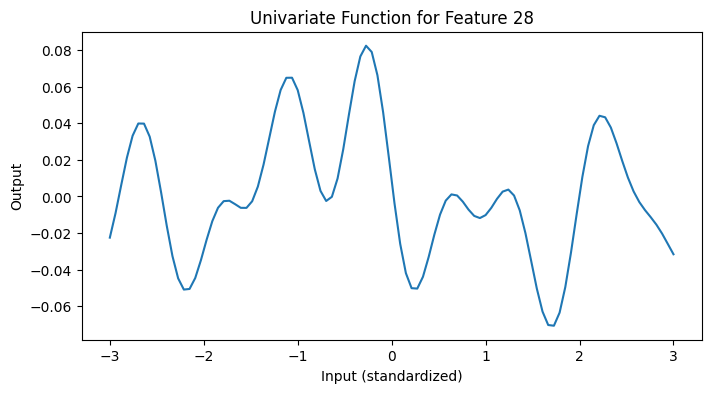

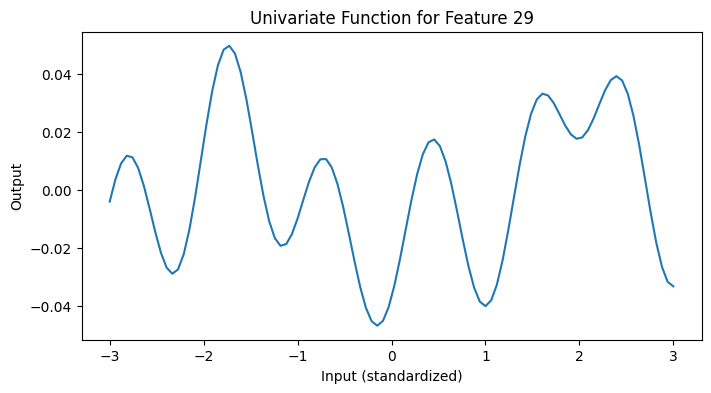

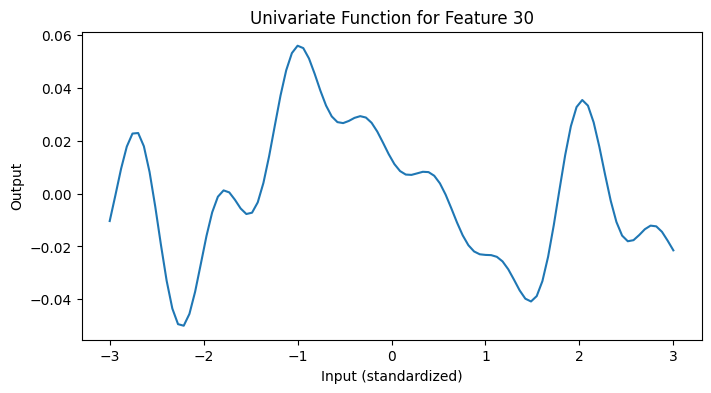

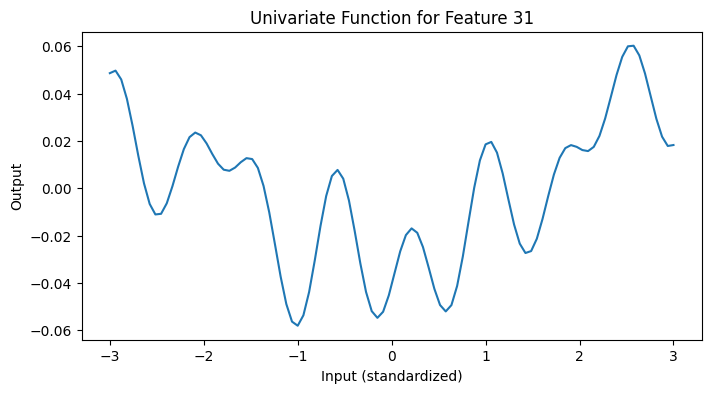

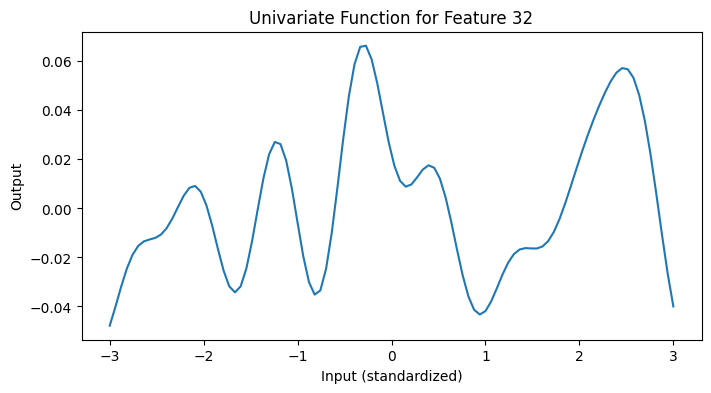

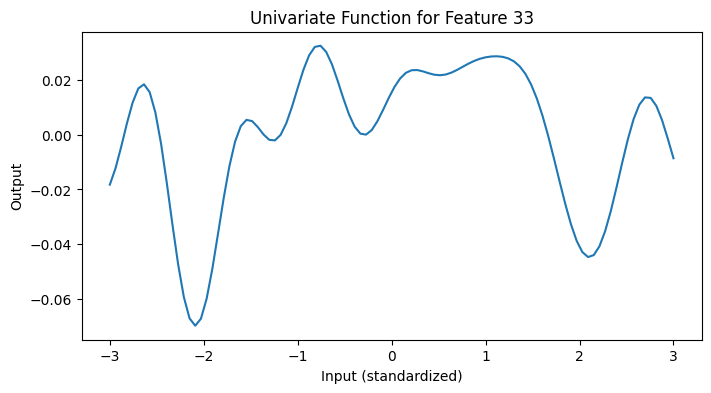

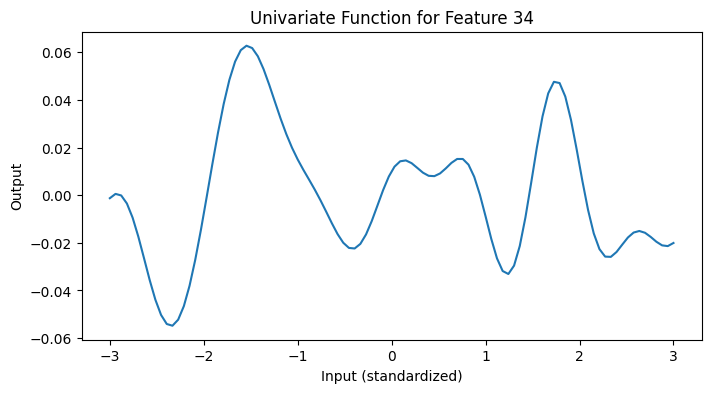

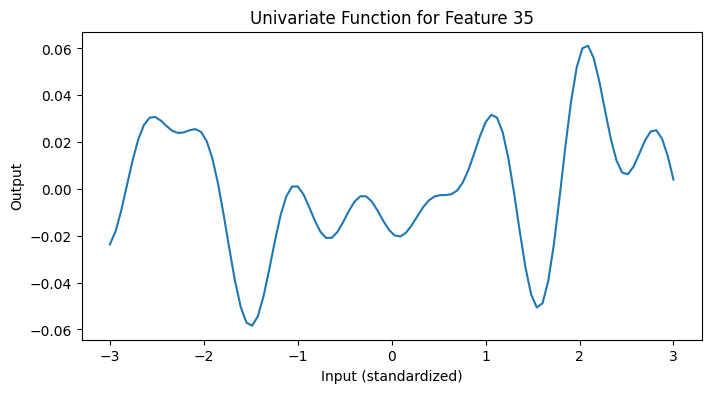

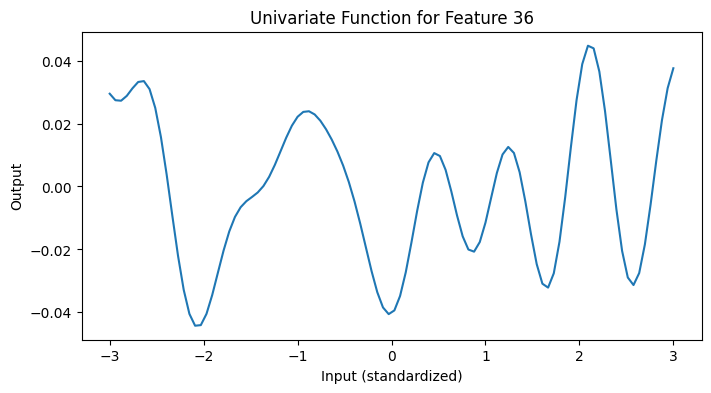

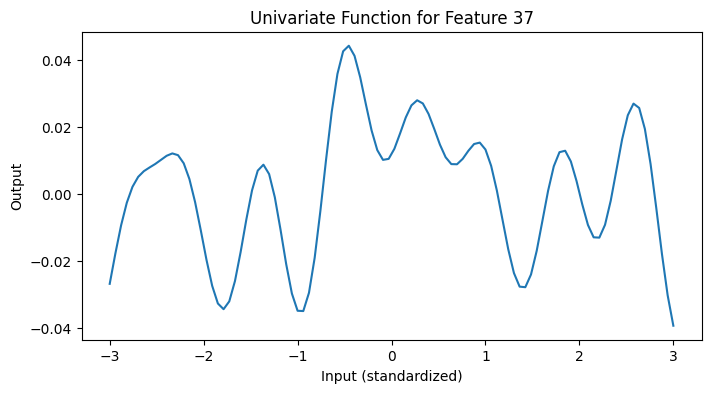

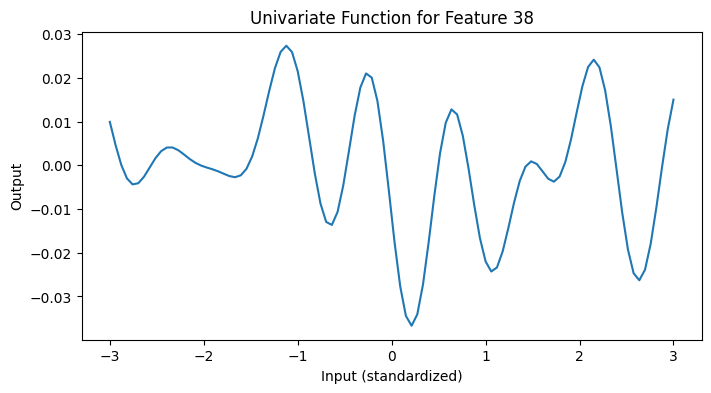

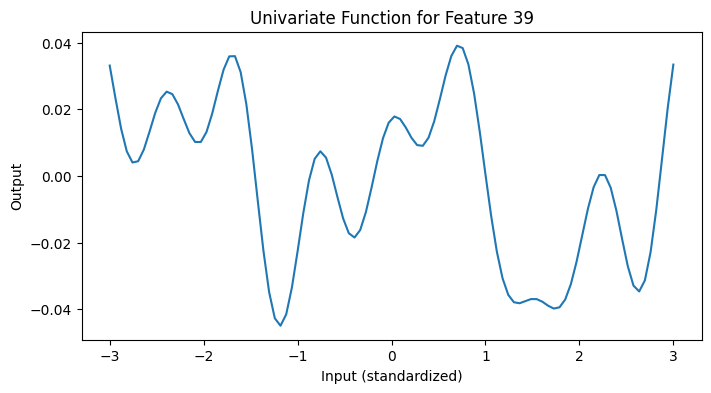

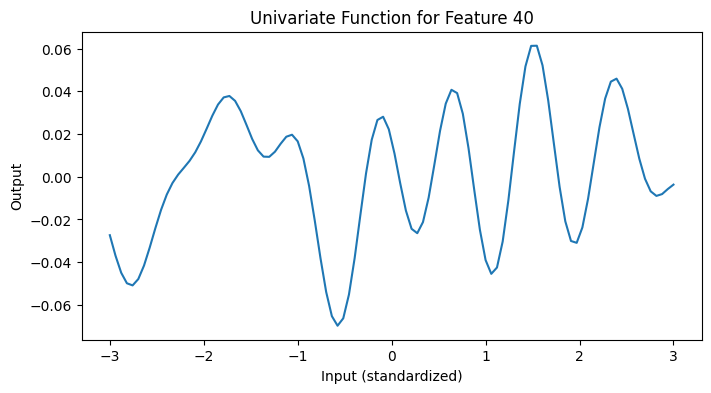

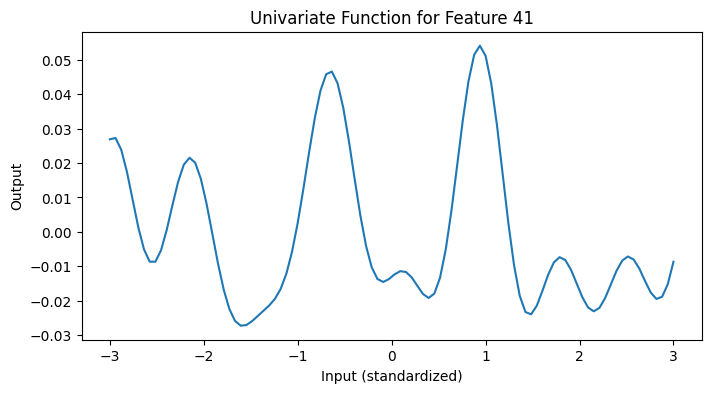

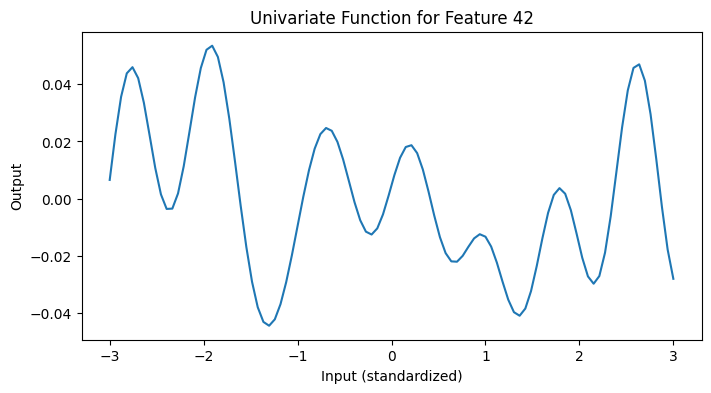

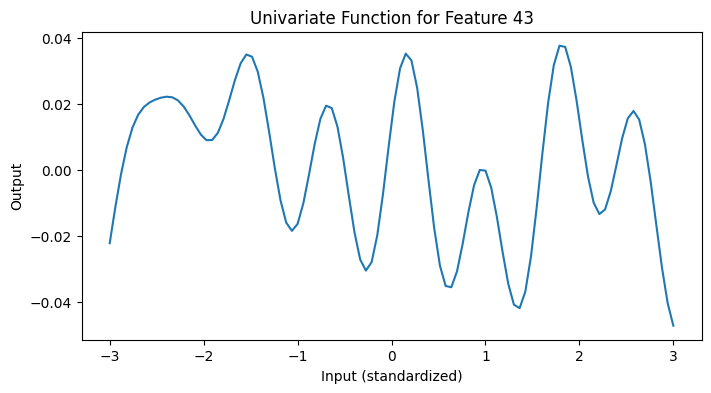

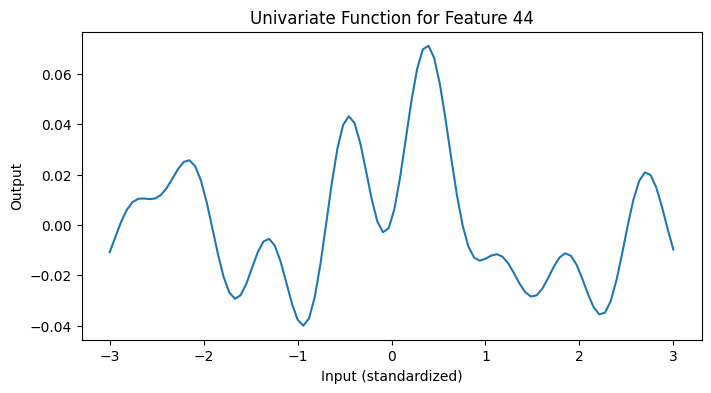

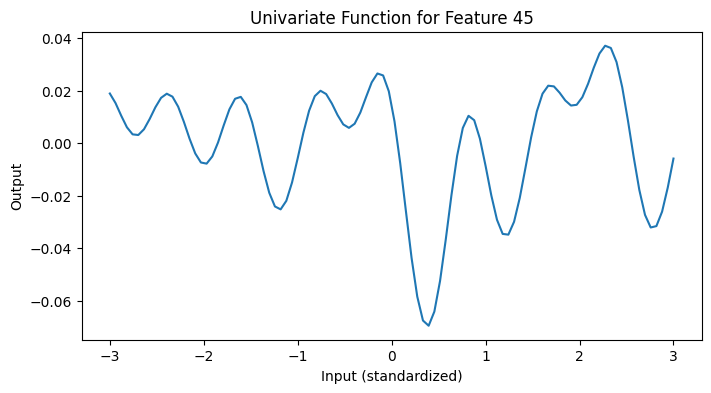

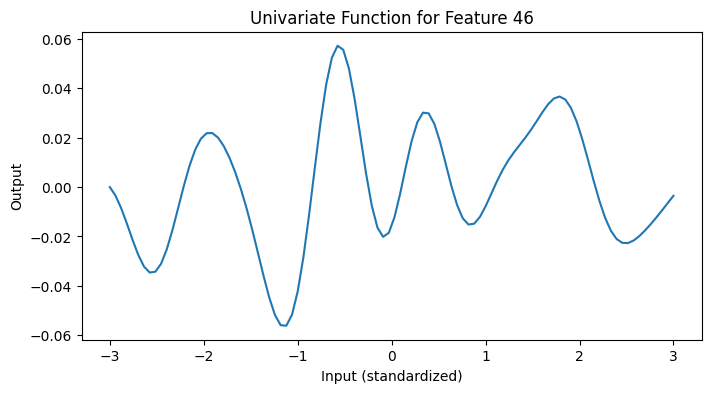

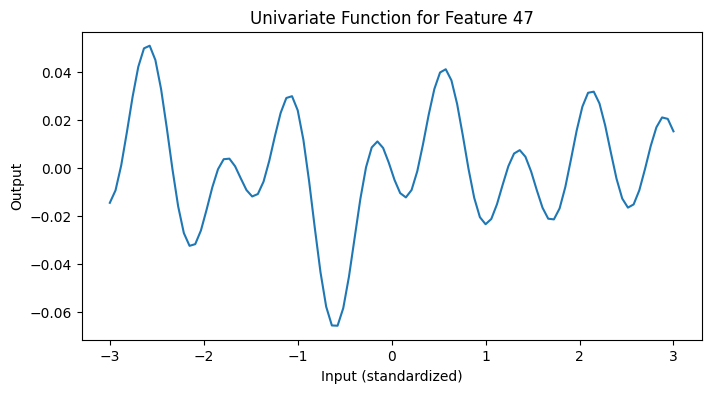

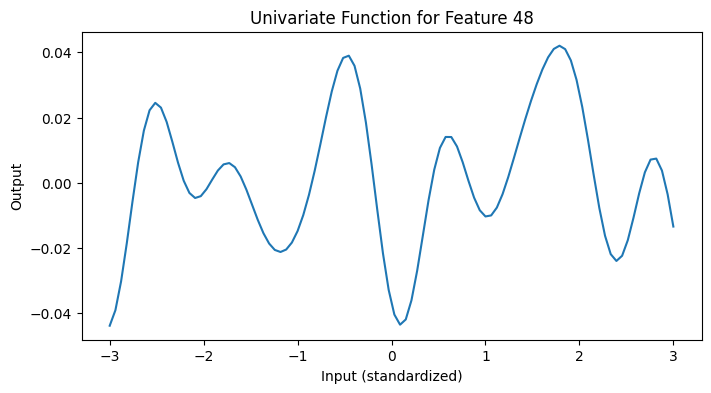

In [20]:
for feature_idx in range(inputdim):
    y = fourier_series(x, cos_coeffs, sin_coeffs, gridsize, feature_idx)
    
    plt.figure(figsize=(8, 4))
    plt.plot(x, y)
    plt.title(f'Univariate Function for Feature {feature_idx}')
    plt.xlabel('Input (standardized)')
    plt.ylabel('Output')
    plt.show()